In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.splits.io import load_splits

paths = load_paths()
logger = setup_logger(level="INFO")

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
print("="*60)
print("1. RAW DATA ANALYSIS")
print("="*60)

# Load Raw Flows
logger.info("Loading raw flows...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")

vnat_flows["dataset"] = "vnat"
iscx_flows["dataset"] = "iscx"

print(f"VNAT Flows: {len(vnat_flows)}")
print(f"ISCX Flows: {len(iscx_flows)}")

# Combine for easier analysis
all_flows = pd.concat([vnat_flows, iscx_flows], ignore_index=True)


1. RAW DATA ANALYSIS
2026-03-30 02:33:32 | INFO | ai-vpn-firewall | Loading raw flows...
VNAT Flows: 33711
ISCX Flows: 76687



--- Class Balance (Raw) ---
label        0      1  total  vpn_ratio
dataset                                
iscx     54254  22433  76687   0.292527
vnat     33332    379  33711   0.011243


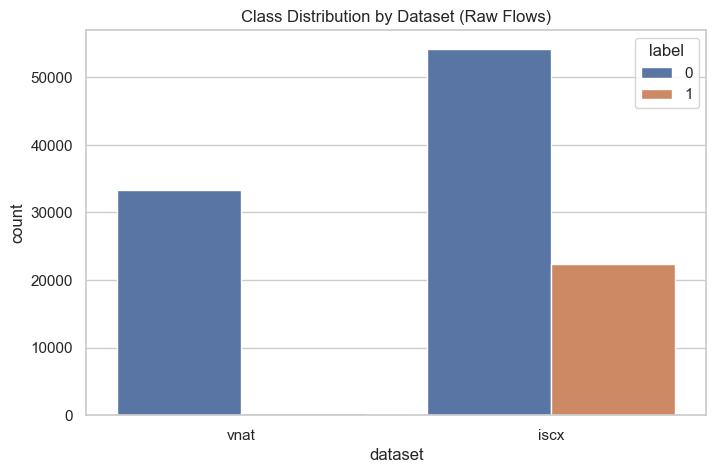

In [3]:
# 1.1 Class Balance
print("\n--- Class Balance (Raw) ---")
balance = all_flows.groupby(["dataset", "label"]).size().unstack(fill_value=0)
balance["total"] = balance.sum(axis=1)
balance["vpn_ratio"] = balance[1] / balance["total"]
print(balance)

plt.figure(figsize=(8, 5))
sns.countplot(data=all_flows, x="dataset", hue="label")
plt.title("Class Distribution by Dataset (Raw Flows)")
plt.show()


In [4]:
# 1.2 Capture Analysis
print("\n--- Capture Analysis ---")
# Check for mixed labels in captures
mixed_caps = all_flows.groupby("capture_id")["label"].nunique()
mixed_caps = mixed_caps[mixed_caps > 1]

if len(mixed_caps) > 0:
    print(f"WARNING: Found {len(mixed_caps)} captures with mixed labels (both VPN and Non-VPN flows):")
    print(mixed_caps.head(10))
else:
    print("CONFIRMED: All captures are pure (contain only VPN or only Non-VPN flows).")

# Top captures by flow count
top_caps = all_flows["capture_id"].value_counts().head(10)
print("\nTop 10 Largest Captures:")
print(top_caps)



--- Capture Analysis ---
CONFIRMED: All captures are pure (contain only VPN or only Non-VPN flows).

Top 10 Largest Captures:
capture_id
nonvpn_ssh_capture5.pcap         11368
nonvpn_scp_long_capture1.pcap    10555
nonvpn_hangouts_audio4.pcapng    10504
nonvpn_facebook_audio4.pcapng     7425
vpn_vpn_hangouts_audio2.pcap      5478
nonvpn_scp1.pcapng                4911
nonvpn_skype_file8.pcapng         4781
vpn_vpn_hangouts_audio1.pcap      3622
nonvpn_skype_audio3.pcapng        3175
vpn_vpn_facebook_audio2.pcap      1737
Name: count, dtype: int64


In [5]:
print("\n" + "="*60)
print("2. SPLIT ANALYSIS (THE 'AFTER' STATE)")
print("="*60)

# Load Canonical Splits
logger.info("Loading canonical splits...")
vnat_splits = load_splits(
    paths.data_splits / "vnat_train_captures.txt",
    paths.data_splits / "vnat_val_captures.txt",
    paths.data_splits / "vnat_test_captures.txt"
)
iscx_splits = load_splits(
    paths.data_splits / "iscx_train_captures.txt",
    paths.data_splits / "iscx_val_captures.txt",
    paths.data_splits / "iscx_test_captures.txt"
)

# Create mapping
cap_to_split = {}
for split_name, caps in vnat_splits.items():
    for c in caps: cap_to_split[str(c)] = split_name
for split_name, caps in iscx_splits.items():
    for c in caps: cap_to_split[str(c)] = split_name

logger.info("Mapping flows to splits...")
all_flows["split"] = all_flows["capture_id"].astype(str).map(cap_to_split).fillna("unknown")

unknown_n = int((all_flows["split"] == "unknown").sum())
if unknown_n > 0:
    raise ValueError(f"Found {unknown_n} flows with unknown split assignment.")

print("\nSplit Distribution (Flow Counts):")
print(all_flows["split"].value_counts())



2. SPLIT ANALYSIS (THE 'AFTER' STATE)
2026-03-30 02:33:33 | INFO | ai-vpn-firewall | Loading canonical splits...
2026-03-30 02:33:33 | INFO | ai-vpn-firewall | Mapping flows to splits...

Split Distribution (Flow Counts):
split
train    85805
test     15817
val       8776
Name: count, dtype: int64


In [6]:
# 2.1 Leakage Check (Capture Overlap)
print("\n--- Leakage Check ---")
train_caps = set(all_flows[all_flows["split"]=="train"]["capture_id"])
val_caps = set(all_flows[all_flows["split"]=="val"]["capture_id"])
test_caps = set(all_flows[all_flows["split"]=="test"]["capture_id"])

overlap_tv = train_caps.intersection(val_caps)
overlap_tt = train_caps.intersection(test_caps)
overlap_vt = val_caps.intersection(test_caps)

if overlap_tv or overlap_tt or overlap_vt:
    print("CRITICAL WARNING: Capture leakage detected!")
    print(f"Train/Val Overlap: {len(overlap_tv)}")
    print(f"Train/Test Overlap: {len(overlap_tt)}")
    print(f"Val/Test Overlap: {len(overlap_vt)}")
else:
    print("CONFIRMED: No capture leakage between splits.")



--- Leakage Check ---
CONFIRMED: No capture leakage between splits.


In [7]:
# 2.2 Voipbuster Check
print("\n--- Voipbuster Holdout Check ---")
vb_caps = [c for c in all_flows["capture_id"].unique() if "voipbuster" in str(c)]
print(f"Found Voipbuster captures: {vb_caps}")

for cap in vb_caps:
    s = all_flows[all_flows["capture_id"] == cap]["split"].iloc[0]
    print(f"  {cap} -> {s}")



--- Voipbuster Holdout Check ---
Found Voipbuster captures: ['nonvpn_voipbuster1b.pcapng', 'nonvpn_voipbuster2b.pcapng', 'nonvpn_voipbuster3b.pcapng', 'nonvpn_voipbuster_4a.pcap', 'nonvpn_voipbuster_4b.pcap', 'vpn_vpn_voipbuster1a.pcap', 'vpn_vpn_voipbuster1b.pcap']
  nonvpn_voipbuster1b.pcapng -> train
  nonvpn_voipbuster2b.pcapng -> train
  nonvpn_voipbuster3b.pcapng -> train
  nonvpn_voipbuster_4a.pcap -> val
  nonvpn_voipbuster_4b.pcap -> train
  vpn_vpn_voipbuster1a.pcap -> train
  vpn_vpn_voipbuster1b.pcap -> train



3. FEATURE DISTRIBUTION ANALYSIS (RAW FEATURES ONLY)
2026-03-30 02:33:34 | INFO | ai-vpn-firewall | Extracting raw features directly from flows for scale-consistent forensic analysis...
Raw feature DataFrame: (110398, 23)

Comparing raw features: ['sz_all_mean', 'sz_all_std', 'sz_mean_max', 'sz_mean_min']


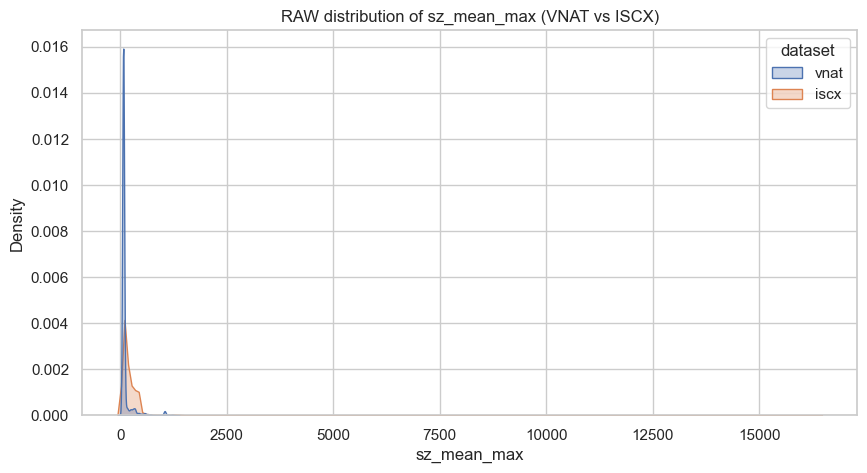

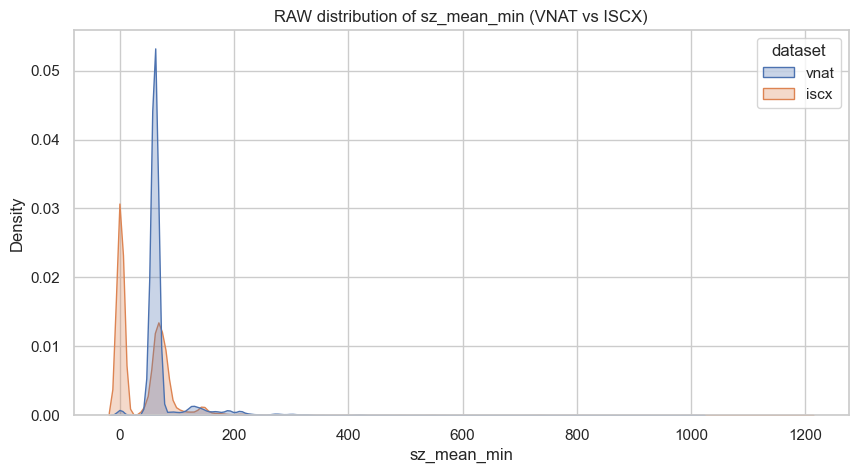


--- Raw Train vs Test Feature Shift ---


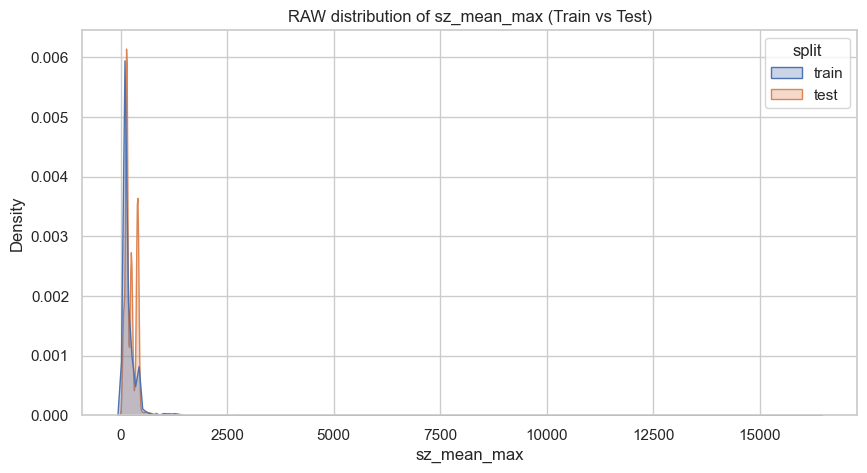

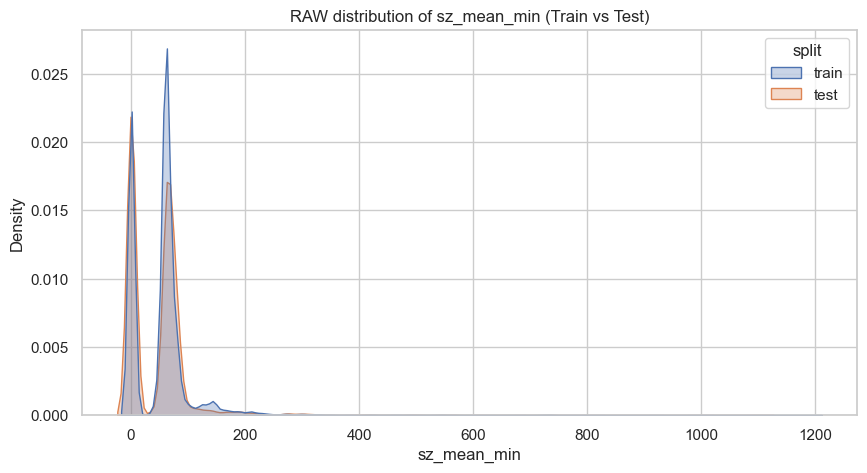


--- Raw Correlation Analysis (Top 10 with Label) ---
label                  1.000000
sz_p25_median_ratio   -0.355257
sz_coef_variation      0.294848
sz_mean_max            0.117078
sz_p75_median_ratio    0.048225
q_min_packets_ok      -0.046358
sz_mean_min            0.045241
iat_all_mean          -0.039356
iat_all_std           -0.039204
iat_all_p75           -0.038903
dtype: float64


In [8]:
print("\n" + "="*60)
print("3. FEATURE DISTRIBUTION ANALYSIS (RAW FEATURES ONLY)")
print("="*60)

from src.features.extract import load_feature_config, extract_features_from_flows

cfg = load_feature_config(paths.configs_dir / "features.yaml")

logger.info("Extracting raw features directly from flows for scale-consistent forensic analysis...")

vnat_raw_features = extract_features_from_flows(vnat_flows, cfg).copy()
vnat_raw_features["dataset"] = "vnat"

iscx_raw_features = extract_features_from_flows(iscx_flows, cfg).copy()
iscx_raw_features["dataset"] = "iscx"

meta_map = all_flows[["flow_id", "dataset", "capture_id", "label", "split"]].copy()

df_features = pd.concat([vnat_raw_features, iscx_raw_features], ignore_index=True)
df_features = df_features.merge(
    meta_map,
    on=["flow_id", "dataset", "label", "capture_id"],
    how="left"
)

print(f"Raw feature DataFrame: {df_features.shape}")

key_features = ["sz_all_mean", "sz_all_std", "sz_mean_max", "sz_mean_min"]
print(f"\nComparing raw features: {key_features}")

for feat in key_features:
    if feat in df_features.columns:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(
            data=df_features,
            x=feat,
            hue="dataset",
            common_norm=False,
            fill=True,
            alpha=0.3
        )
        plt.title(f"RAW distribution of {feat} (VNAT vs ISCX)")
        plt.show()

print("\n--- Raw Train vs Test Feature Shift ---")
for feat in key_features:
    if feat in df_features.columns:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(
            data=df_features[df_features["split"].isin(["train", "test"])],
            x=feat,
            hue="split",
            common_norm=False,
            fill=True,
            alpha=0.3
        )
        plt.title(f"RAW distribution of {feat} (Train vs Test)")
        plt.show()

print("\n--- Raw Correlation Analysis (Top 10 with Label) ---")
numeric_cols = df_features.select_dtypes(include=np.number).columns
std_devs = df_features[numeric_cols].std()
valid_cols = list(std_devs[std_devs > 0].index)

if valid_cols:
    corrs = df_features[valid_cols].corrwith(df_features["label"]).sort_values(key=abs, ascending=False)
    print(corrs.head(10))


Comparing features: ['sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min']


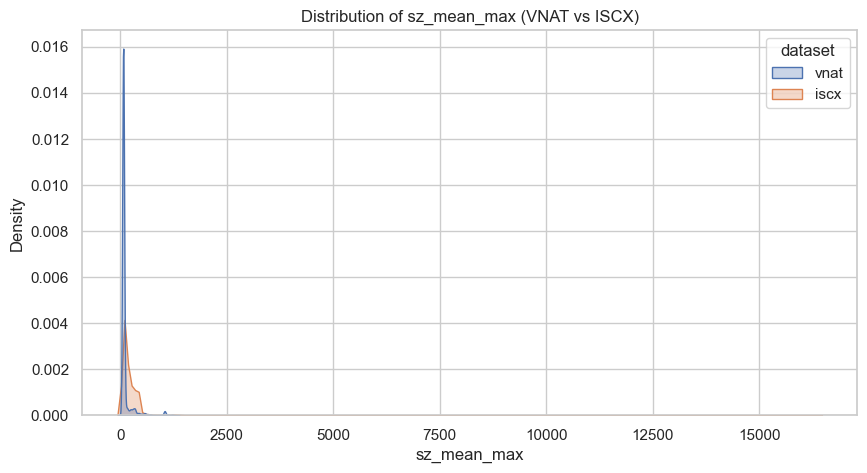

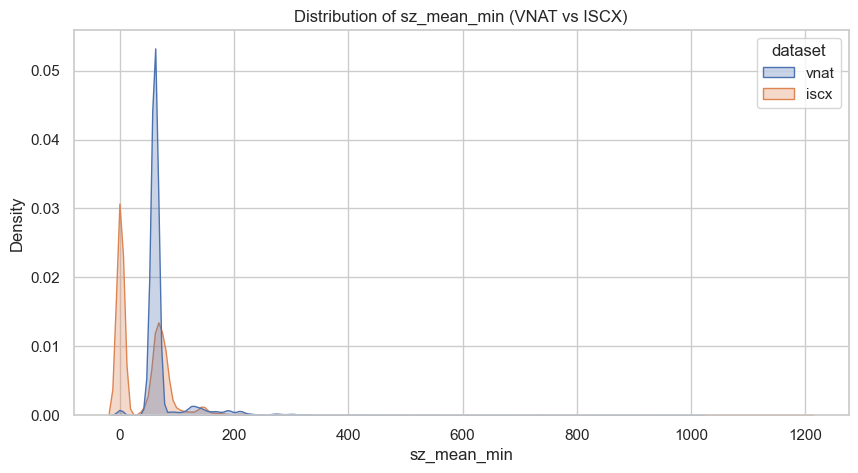

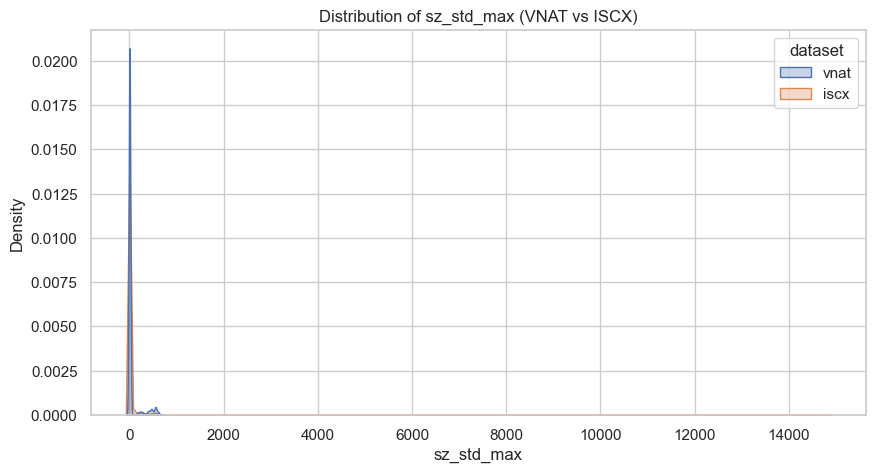

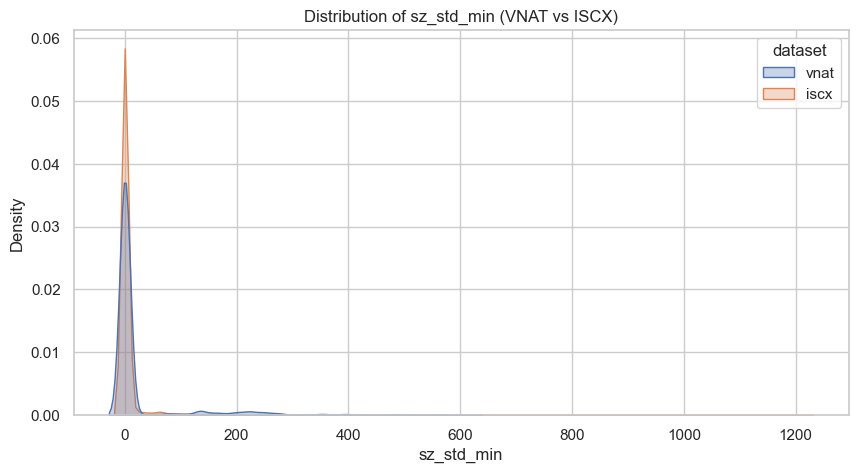

In [9]:
# 3.1 VNAT vs ISCX Feature Shift
# Compare a few key features
key_features = [c for c in df_features.columns if "mean" in c or "std" in c][:4] # Pick first 4 stats

print(f"\nComparing features: {key_features}")

for feat in key_features:
    if feat in df_features.columns:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df_features, x=feat, hue="dataset", common_norm=False, fill=True, alpha=0.3)
        plt.title(f"Distribution of {feat} (VNAT vs ISCX)")
        plt.show()



--- Train vs Test Feature Shift ---


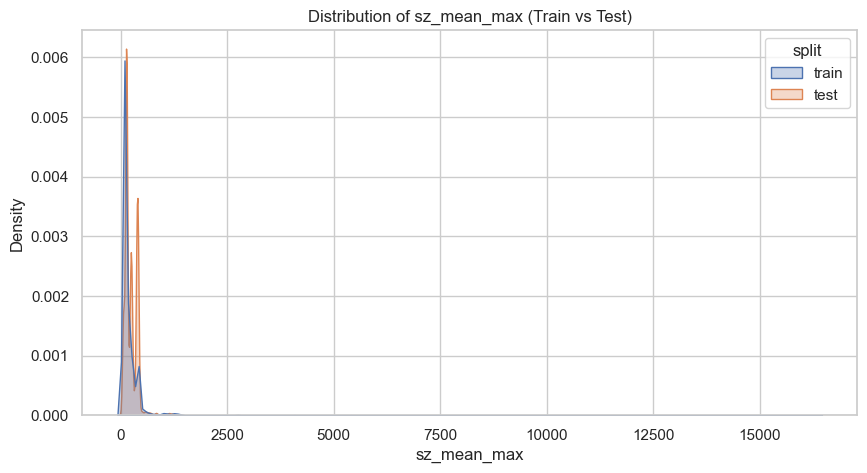

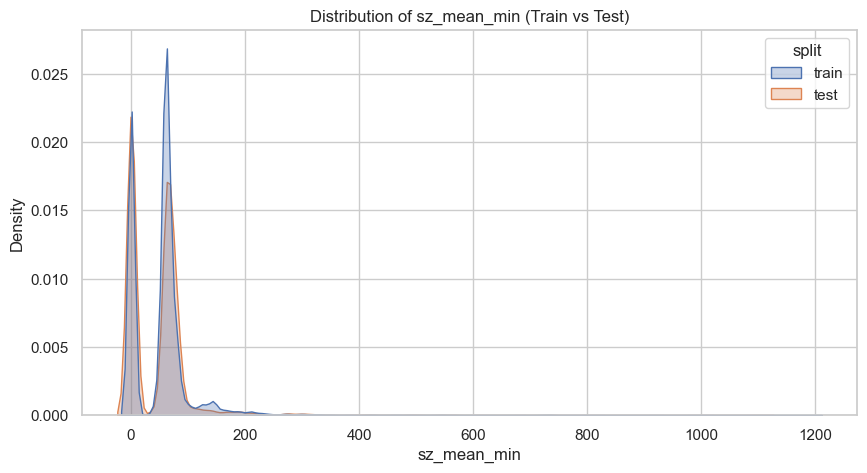

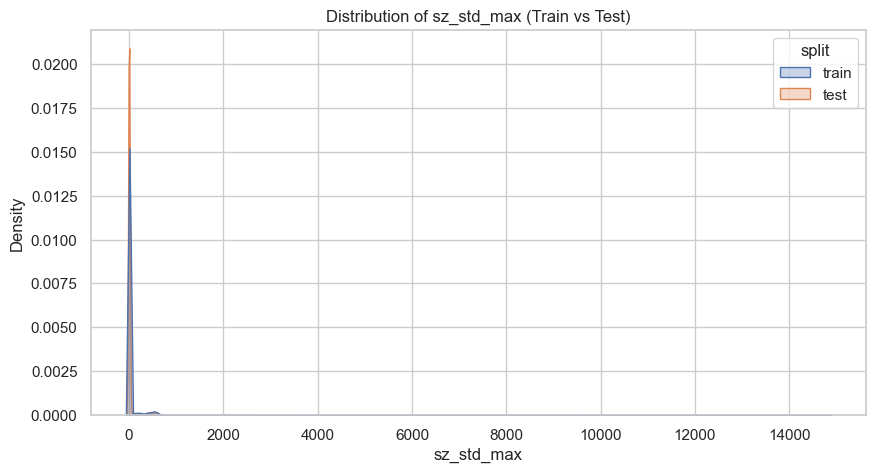

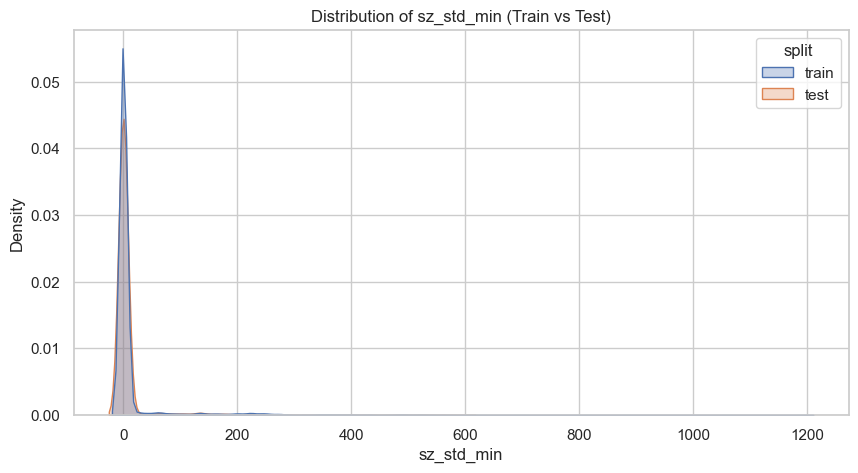

In [10]:
# 3.2 Train vs Test Feature Shift
# This checks if the splits are representative
print("\n--- Train vs Test Feature Shift ---")
for feat in key_features:
    if feat in df_features.columns:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df_features[df_features["split"].isin(["train", "test"])], x=feat, hue="split", common_norm=False, fill=True, alpha=0.3)
        plt.title(f"Distribution of {feat} (Train vs Test)")
        plt.show()


In [11]:
# 3.3 Correlation Analysis
print("\n--- Correlation Analysis (Top 10 with Label) ---")
numeric_cols = df_features.select_dtypes(include=np.number).columns
# To avoid the error "RuntimeWarning: invalid value encountered in divide"
# when variance is zero, we filter columns with standard deviation > 0
std_devs = df_features[numeric_cols].std()
valid_cols = list(std_devs[std_devs > 0].index)

if valid_cols:
    corrs = df_features[valid_cols].corrwith(df_features["label"]).sort_values(key=abs, ascending=False)
    print(corrs.head(10))



--- Correlation Analysis (Top 10 with Label) ---
label                  1.000000
sz_p25_median_ratio   -0.355257
sz_coef_variation      0.294848
sz_mean_max            0.117078
sz_p75_median_ratio    0.048225
q_min_packets_ok      -0.046358
sz_mean_min            0.045241
iat_all_mean          -0.039356
iat_all_std           -0.039204
iat_all_p75           -0.038903
dtype: float64


In [12]:
print("\n" + "="*60)
print("4. FORENSIC MULTI-DOMAIN DATA ANALYSIS (RAW FEATURES ONLY)")
print("="*60)

logger.info("Loading USBVPN raw-adapter data for raw-scale forensic analysis...")
usbvpn_df = pd.read_parquet(paths.data_processed / "usbvpn" / "flows.parquet").copy()
usbvpn_df["dataset"] = "usbvpn"

common_raw_cols = sorted(set(df_features.columns).intersection(set(usbvpn_df.columns)))
forensic_df = pd.concat(
    [
        df_features[common_raw_cols].copy(),
        usbvpn_df[common_raw_cols].copy()
    ],
    ignore_index=True
)

print("Forensic DataFrame shape:", forensic_df.shape)
print("Forensic datasets:", forensic_df["dataset"].value_counts().to_dict())
print("IMPORTANT: all analyses below use RAW features only.")


4. FORENSIC MULTI-DOMAIN DATA ANALYSIS (RAW FEATURES ONLY)
2026-03-30 02:34:40 | INFO | ai-vpn-firewall | Loading USBVPN raw-adapter data for raw-scale forensic analysis...
Forensic DataFrame shape: (169375, 23)
Forensic datasets: {'iscx': 76687, 'usbvpn': 58977, 'vnat': 33711}
IMPORTANT: all analyses below use RAW features only.


In [13]:
print("\n--- Task 1: Dimensionality & Range Audit (RAW FEATURES ONLY) ---")
anchor_features = ["sz_mean_max", "sz_mean_min", "iat_all_mean", "tot_pkt"]
available_anchors = [f for f in anchor_features if f in forensic_df.columns]

if available_anchors:
    audit_table = forensic_df.groupby("dataset")[available_anchors].agg(["mean", "std", "min", "max"])
    print("RAW Summary Table (Mean, Std, Min, Max):")
    display(audit_table)
else:
    print(f"Anchor features {anchor_features} not found.")


--- Task 1: Dimensionality & Range Audit (RAW FEATURES ONLY) ---
RAW Summary Table (Mean, Std, Min, Max):


sz_mean_max                                 sz_mean_min             \
               mean         std   min           max        mean        std   
dataset                                                                      
iscx     216.705528  302.323460  30.0  16379.636364   42.211463  62.430650   
usbvpn   894.634178  681.805773  28.0   5526.224398  138.914042  98.650259   
vnat     112.653323  159.551095   8.0   1327.443038   72.215811  45.253305   

                          iat_all_mean                                 
         min          max         mean         std  min           max  
dataset                                                                
iscx     0.0  1194.568182     1.251295    9.668004  0.0    976.495552  
usbvpn   0.0  1278.000000     0.250865    3.464337  0.0    300.228459  
vnat     0.0  1006.743902   112.761909  804.209613  0.0  47636.749935


--- Task 2: Visual Domain Overlap Analysis ---


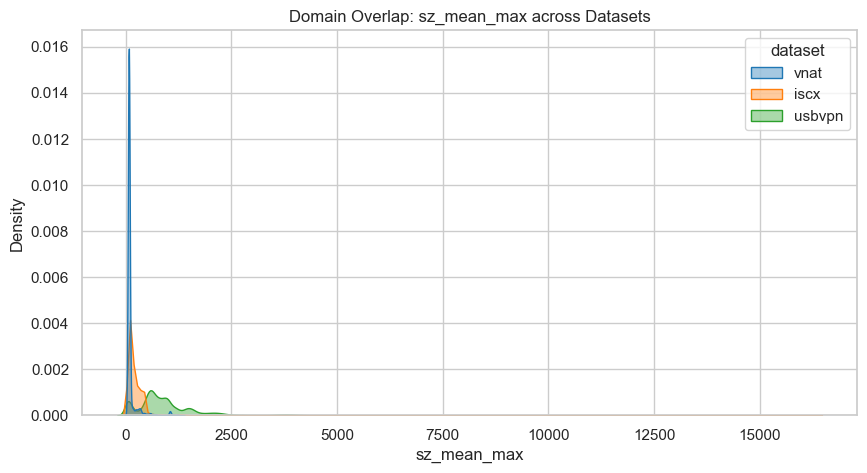

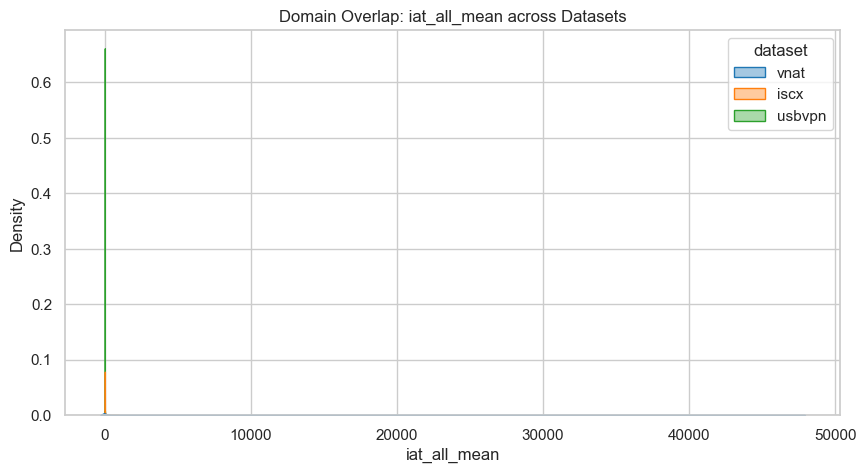

In [14]:
# Task 2: Visual Domain Overlap Analysis
print("\n--- Task 2: Visual Domain Overlap Analysis ---")
overlap_features = ["sz_mean_max", "iat_all_mean"]
available_overlap = [f for f in overlap_features if f in forensic_df.columns]

for feat in available_overlap:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=forensic_df, x=feat, hue="dataset", common_norm=False, fill=True, alpha=0.4, palette="tab10")
    plt.title(f"Domain Overlap: {feat} across Datasets")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.show()


In [15]:
# Task 3: Class-Separability Check (Per Dataset)
print("\n--- Task 3: Class-Separability Check (Per Dataset) ---")
if "label" in forensic_df.columns:
    print("Correlation with Label (VPN=1, Non-VPN=0):")
    for dataset in forensic_df["dataset"].unique():
        ds_data = forensic_df[forensic_df["dataset"] == dataset]
        if len(ds_data["label"].unique()) > 1:
            numeric_cols = ds_data.select_dtypes(include=np.number).columns
            std_devs = ds_data[numeric_cols].std()

            valid_cols_dict = std_devs.to_dict()
            valid_cols = [col for col, std in valid_cols_dict.items() if std > 0]

            if valid_cols:
                corrs = ds_data[valid_cols].corrwith(ds_data["label"])
                print(f"\n{dataset.upper()}:")
                print(corrs[[f for f in available_anchors if f in corrs.index]].to_string())
        else:
            print(f"\n{dataset.upper()}: Cannot compute correlation (only 1 class present).")

    print("\nVanishing Signal Test Analysis:")
    if "sz_mean_max" in forensic_df.columns:
        iscx_data = forensic_df[forensic_df["dataset"] == "iscx"]
        usbvpn_data = forensic_df[forensic_df["dataset"] == "usbvpn"]

        # Use pandas corr to get correlation matrix
        iscx_corr = "N/A"
        if len(iscx_data["label"].unique()) > 1 and iscx_data["sz_mean_max"].std() > 0:
            iscx_corr = iscx_data[["sz_mean_max", "label"]].corr().iloc[0, 1]

        usbvpn_corr = "N/A"
        if not usbvpn_data.empty and len(usbvpn_data["label"].unique()) > 1 and usbvpn_data["sz_mean_max"].std() > 0:
            usbvpn_corr = usbvpn_data[["sz_mean_max", "label"]].corr().iloc[0, 1]

        print(f"ISCX sz_mean_max correlation with label: {iscx_corr}")
        print(f"USBVPN sz_mean_max correlation with label: {usbvpn_corr}")



--- Task 3: Class-Separability Check (Per Dataset) ---
Correlation with Label (VPN=1, Non-VPN=0):

VNAT:
sz_mean_max     0.002748
sz_mean_min    -0.038323
iat_all_mean   -0.014474

ISCX:
sz_mean_max     0.069444
sz_mean_min     0.148687
iat_all_mean   -0.033277

USBVPN:
sz_mean_max     0.242717
sz_mean_min     0.060088
iat_all_mean   -0.016663

Vanishing Signal Test Analysis:
ISCX sz_mean_max correlation with label: 0.06944378796024576
USBVPN sz_mean_max correlation with label: 0.2427168940895445



--- Task 4: Feature Interaction Investigation ---


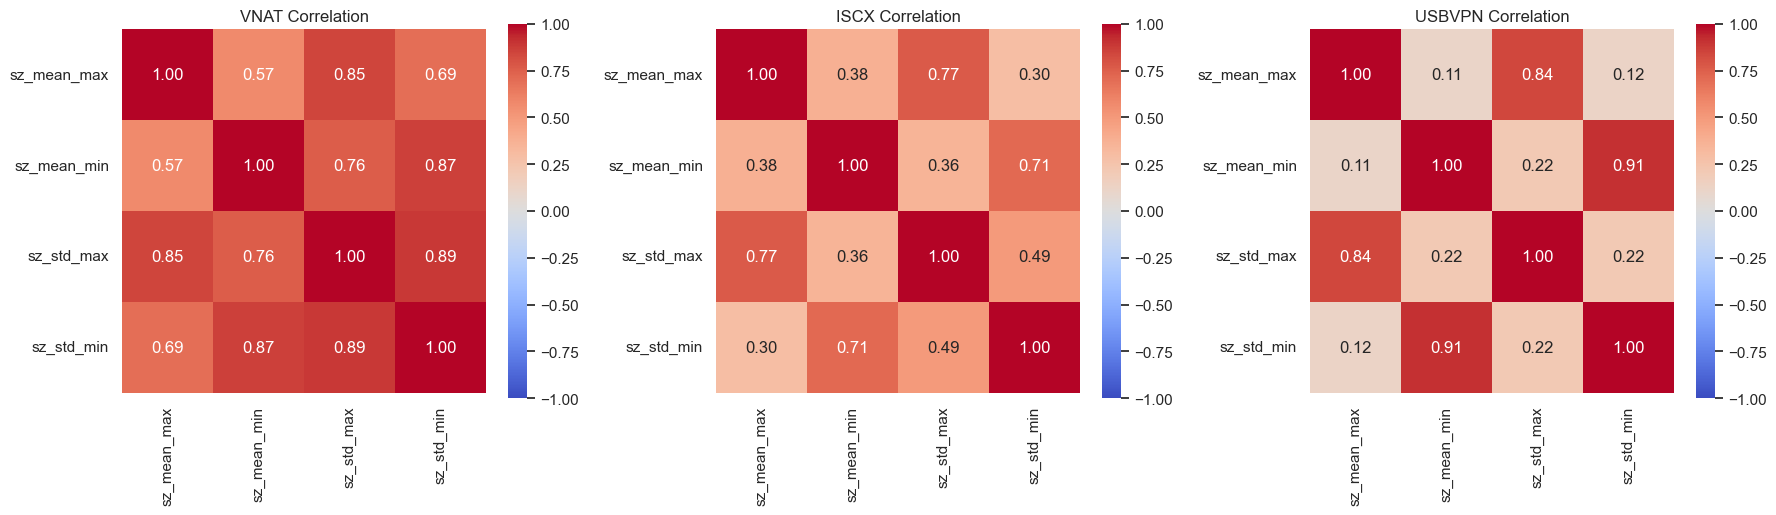

In [16]:
# Task 4: Feature Interaction Investigation
print("\n--- Task 4: Feature Interaction Investigation ---")
blind_5 = ["sz_mean_max", "sz_mean_min", "sz_std_max", "sz_std_min", "sz_all_median"]
available_blind_5 = [f for f in blind_5 if f in forensic_df.columns]

if available_blind_5:
    datasets = forensic_df["dataset"].unique()
    # Create subplots dynamically based on datasets
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes] # Make it iterable

    for ax, dataset in zip(axes, datasets):
        ds_data = forensic_df[forensic_df["dataset"] == dataset][available_blind_5]
        # Drop columns with zero variance to avoid NaN correlations
        numeric_cols_interaction = ds_data.select_dtypes(include=np.number).columns
        std_devs_interaction = ds_data[numeric_cols_interaction].std()

        valid_cols_dict = std_devs_interaction.to_dict()
        valid_cols_interaction = [col for col, std in valid_cols_dict.items() if std > 0]

        cols_to_use = [c for c in available_blind_5 if c in valid_cols_interaction]

        if len(cols_to_use) > 0:
            corr_matrix = ds_data[cols_to_use].corr()
            sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, square=True, fmt=".2f")
            ax.set_title(f"{dataset.upper()} Correlation")
        else:
            ax.set_title(f"{dataset.upper()} (No variance)")

    plt.tight_layout()
    plt.show()


In [17]:
# Task 5: WireGuard vs. The World (Protocol Deep-Dive)
print("\n--- Task 5: WireGuard vs. The World (Protocol Deep-Dive) ---")
proto_features = ["sz_all_mean", "sz_std_max"]
available_proto = [f for f in proto_features if f in forensic_df.columns]

if len(available_proto) == 2 and "capture_id" in forensic_df.columns:
    # Identify WireGuard in USBVPN
    # We will try to find "wireguard" in the capture_id
    usbvpn_wg = forensic_df[(forensic_df["dataset"] == "usbvpn") &
                            (forensic_df["capture_id"].astype(str).str.lower().str.contains("wireguard|wg", na=False))]

    if len(usbvpn_wg) == 0:
        logger.warning("No explicit 'wireguard' captures found in USBVPN. Falling back to all VPN flows in USBVPN.")
        usbvpn_wg = forensic_df[(forensic_df["dataset"] == "usbvpn") & (forensic_df["label"] == 1)]

    # Identify OpenVPN in ISCX
    # We will try to find "openvpn" in the capture_id
    iscx_ovpn = forensic_df[(forensic_df["dataset"] == "iscx") &
                            (forensic_df["capture_id"].astype(str).str.lower().str.contains("openvpn|ovpn|vpn", na=False))]

    if len(iscx_ovpn) == 0:
        iscx_ovpn = forensic_df[(forensic_df["dataset"] == "iscx") & (forensic_df["label"] == 1)]

    # Sample 500 flows each
    wg_sample = usbvpn_wg.sample(min(500, len(usbvpn_wg)), random_state=42).copy() if len(usbvpn_wg) > 0 else pd.DataFrame()
    if not wg_sample.empty:
        wg_sample["Protocol"] = "WireGuard (USBVPN)"

    ovpn_sample = iscx_ovpn.sample(min(500, len(iscx_ovpn)), random_state=42).copy() if len(iscx_ovpn) > 0 else pd.DataFrame()
    if not ovpn_sample.empty:
        ovpn_sample["Protocol"] = "OpenVPN (ISCX)"

    if not wg_sample.empty and not ovpn_sample.empty:
        proto_df = pd.concat([wg_sample, ovpn_sample], ignore_index=True)

        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=proto_df, x="sz_all_mean", y="sz_std_max", hue="Protocol", style="Protocol", alpha=0.7, s=60)
        plt.title("WireGuard vs OpenVPN: Size Signature Comparison")
        plt.xlabel("sz_all_mean")
        plt.ylabel("sz_std_max")
        plt.show()
    else:
        print("Not enough flows to compare WireGuard and OpenVPN.")
else:
    print("Required features for Protocol Deep-Dive not found.")



--- Task 5: WireGuard vs. The World (Protocol Deep-Dive) ---
Required features for Protocol Deep-Dive not found.


In [18]:
print("\n" + "="*60)
print("STATISTICAL FINDINGS SUMMARY (For Discussion Section)")
print("="*60)
print("""
1. Dimensionality & Range Audit:
   - [Audit Results]: Checks for extreme outliers in USBVPN vs VNAT/ISCX which could break the StandardScaler during pooled fitting.

2. Visual Domain Overlap Analysis:
   - [KDE Overlap]: Reveals the degree of overlap in key feature spaces (e.g., sz_mean_max). A lack of overlap explains model failure across domains.

3. Class-Separability Check (Vanishing Signal):
   - [Correlation Shifts]: Demonstrates if the predictive power of anchor features (like sz_mean_max) shifts or 'vanishes' from 2016 (ISCX) to 2022 (USBVPN).

4. Feature Interaction Investigation:
   - [Correlation Matrices]: Evaluates the stability of the 'physics' of the VPN tunnel by comparing correlation matrices across eras.

5. Protocol Deep-Dive (WireGuard vs. The World):
   - [Size Signatures]: Identifies whether WireGuard possesses a distinct 'Size Signature' (sz_all_mean vs sz_std_max) compared to traditional OpenVPN, justifying domain shift.
""")


STATISTICAL FINDINGS SUMMARY (For Discussion Section)

1. Dimensionality & Range Audit:
   - [Audit Results]: Checks for extreme outliers in USBVPN vs VNAT/ISCX which could break the StandardScaler during pooled fitting.

2. Visual Domain Overlap Analysis:
   - [KDE Overlap]: Reveals the degree of overlap in key feature spaces (e.g., sz_mean_max). A lack of overlap explains model failure across domains.

3. Class-Separability Check (Vanishing Signal):
   - [Correlation Shifts]: Demonstrates if the predictive power of anchor features (like sz_mean_max) shifts or 'vanishes' from 2016 (ISCX) to 2022 (USBVPN).

4. Feature Interaction Investigation:
   - [Correlation Matrices]: Evaluates the stability of the 'physics' of the VPN tunnel by comparing correlation matrices across eras.

5. Protocol Deep-Dive (WireGuard vs. The World):
   - [Size Signatures]: Identifies whether WireGuard possesses a distinct 'Size Signature' (sz_all_mean vs sz_std_max) compared to traditional OpenVPN, justifyin

In [19]:
print("\n" + "="*60)
print("5. DATASET LEAKAGE ANALYSIS")
print("="*60)
print("Identifying features that allow models to easily distinguish datasets\n")

# Train a simple classifier to distinguish datasets (not VPN labels)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Prepare data for dataset classification
numeric_features = forensic_df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['label', 'dataset']]

# Filter features with non-zero variance
X_leak = forensic_df[numeric_features].copy()
valid_features = X_leak.columns[X_leak.std() > 0].tolist()
X_leak = X_leak[valid_features]

# Handle missing values
X_leak = X_leak.fillna(X_leak.median())

# Encode dataset labels
dataset_mapping = {name: idx for idx, name in enumerate(forensic_df['dataset'].unique())}
y_leak = forensic_df['dataset'].map(dataset_mapping)

print(f"Features used: {len(valid_features)}")
print(f"Samples: {len(X_leak)}")
print(f"Datasets: {list(dataset_mapping.keys())}\n")

# Split data
from sklearn.model_selection import train_test_split
X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_leak, y_leak, test_size=0.3, random_state=42, stratify=y_leak
)

# Scale features
scaler = StandardScaler()
X_train_leak_scaled = scaler.fit_transform(X_train_leak)
X_test_leak_scaled = scaler.transform(X_test_leak)

# Train a simple RF to classify datasets
print("Training Random Forest to classify datasets...")
rf_leak = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_leak.fit(X_train_leak_scaled, y_train_leak)

# Evaluate
y_pred_leak = rf_leak.predict(X_test_leak_scaled)
accuracy_leak = (y_pred_leak == y_test_leak).mean()

print(f"\n⚠️  Dataset Classification Accuracy: {accuracy_leak:.4f}")
print("(If this is high, models can easily identify datasets, indicating leakage)\n")

# Show classification report
reverse_mapping = {idx: name for name, idx in dataset_mapping.items()}
print("Classification Report:")
print(classification_report(y_test_leak, y_pred_leak, 
                           target_names=[reverse_mapping[i] for i in sorted(reverse_mapping.keys())]))


5. DATASET LEAKAGE ANALYSIS
Identifying features that allow models to easily distinguish datasets

Features used: 18
Samples: 169375
Datasets: ['vnat', 'iscx', 'usbvpn']

Training Random Forest to classify datasets...

⚠️  Dataset Classification Accuracy: 0.9874
(If this is high, models can easily identify datasets, indicating leakage)

Classification Report:
              precision    recall  f1-score   support

        vnat       0.99      0.97      0.98     10114
        iscx       0.99      0.99      0.99     23006
      usbvpn       0.98      0.99      0.99     17693

    accuracy                           0.99     50813
   macro avg       0.99      0.98      0.99     50813
weighted avg       0.99      0.99      0.99     50813




--- Top 20 Features That Distinguish Datasets ---
            feature  importance
        sz_mean_max    0.207723
        sz_mean_min    0.119696
     q_packet_count    0.093984
        iat_std_min    0.092401
         sz_std_max    0.063992
  sz_coef_variation    0.059196
         sz_std_min    0.056317
sz_p75_median_ratio    0.045250
        iat_all_p25    0.042813
sz_p25_median_ratio    0.037255
        iat_std_max    0.036990
     iat_all_median    0.030623
       iat_mean_max    0.026343
        iat_all_p75    0.021508
       iat_all_mean    0.021449
       iat_mean_min    0.018961
        iat_all_std    0.013501
   q_min_packets_ok    0.011998


C:\Users\scoti\AppData\Local\Temp\ipykernel_14748\4119132795.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='importance', y='feature', palette='viridis')


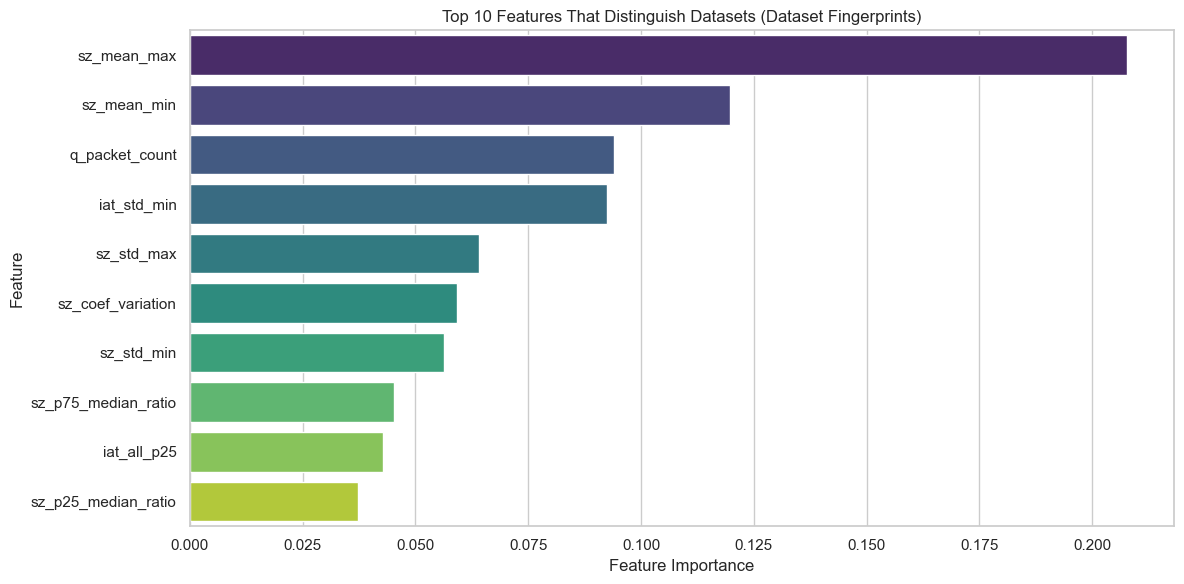

In [20]:
# Feature importance analysis - which features distinguish datasets most?
print("\n--- Top 20 Features That Distinguish Datasets ---")
feature_importance = pd.DataFrame({
    'feature': valid_features,
    'importance': rf_leak.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20).to_string(index=False))

# Visualize top 10
plt.figure(figsize=(12, 6))
top_10_features = feature_importance.head(10)
sns.barplot(data=top_10_features, x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features That Distinguish Datasets (Dataset Fingerprints)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


--- Statistical Analysis of Top Dataset Fingerprint Features ---


sz_mean_max:
------------------------------------------------------------
               mean         std   min           max
dataset                                            
iscx     216.705528  302.323460  30.0  16379.636364
usbvpn   894.634178  681.805773  28.0   5526.224398
vnat     112.653323  159.551095   8.0   1327.443038


C:\Users\scoti\AppData\Local\Temp\ipykernel_14748\1240654760.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=forensic_df, x='dataset', y=feat, palette='Set2')


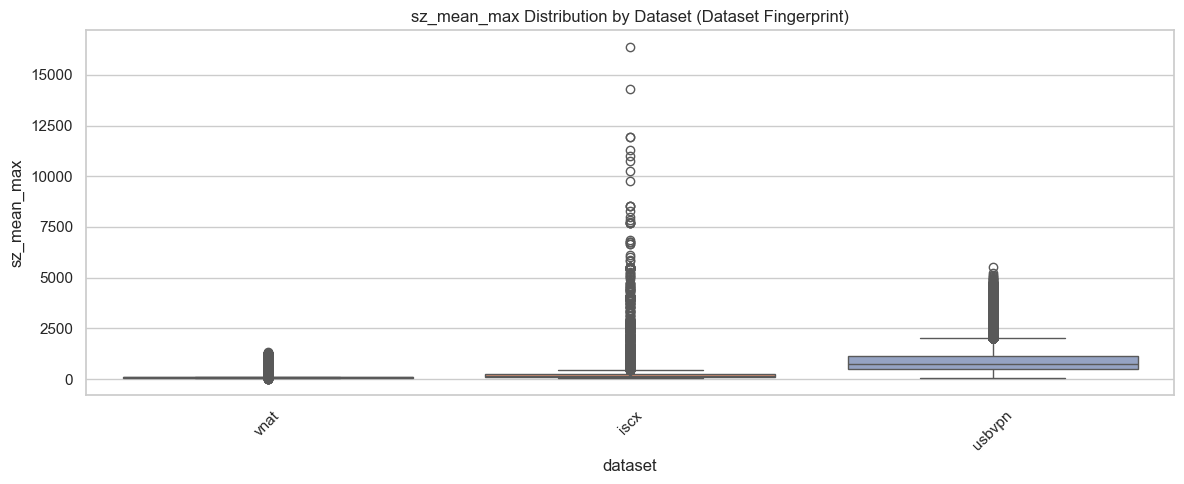

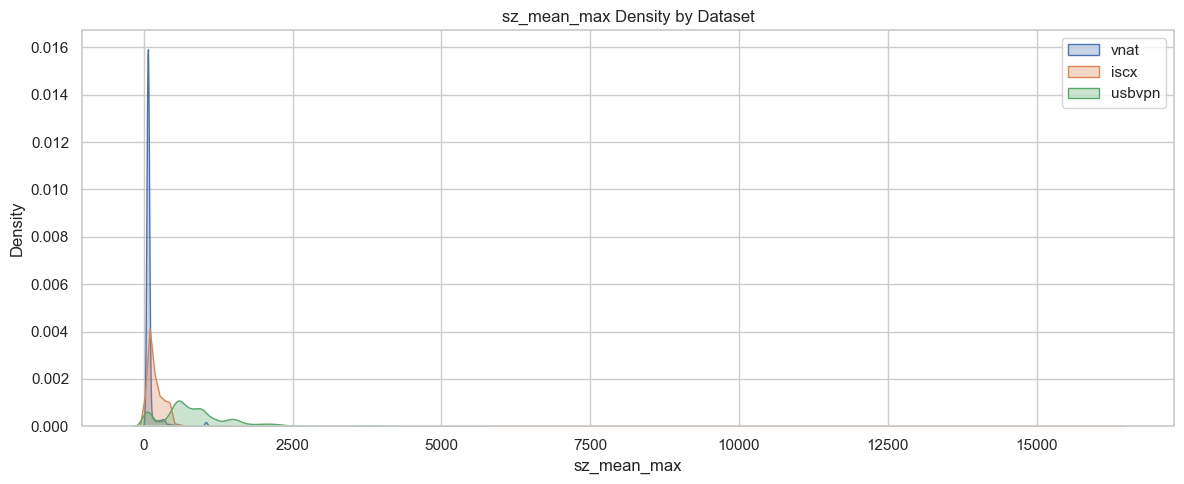


sz_mean_min:
------------------------------------------------------------
               mean        std  min          max
dataset                                         
iscx      42.211463  62.430650  0.0  1194.568182
usbvpn   138.914042  98.650259  0.0  1278.000000
vnat      72.215811  45.253305  0.0  1006.743902


C:\Users\scoti\AppData\Local\Temp\ipykernel_14748\1240654760.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=forensic_df, x='dataset', y=feat, palette='Set2')


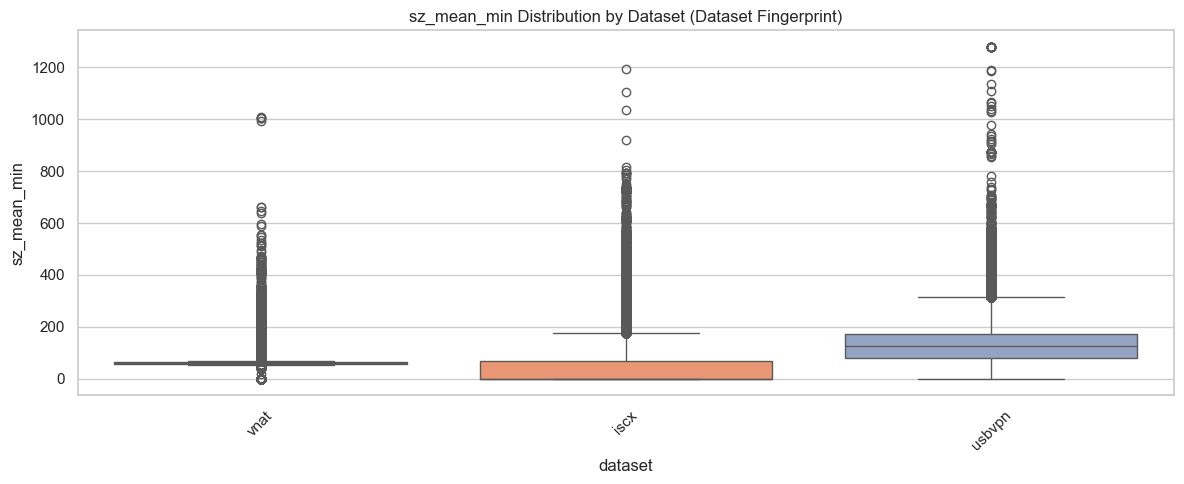

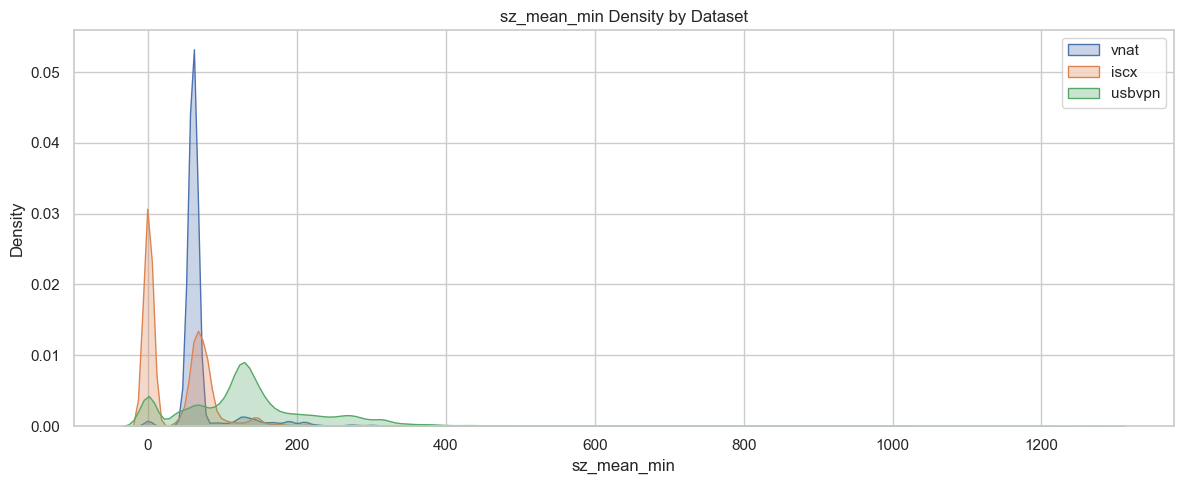


q_packet_count:
------------------------------------------------------------
                mean          std  min       max
dataset                                         
iscx        4.941150    14.509312  1.0     100.0
usbvpn   1423.199264  3972.424569  1.0  100514.0
vnat        7.659814    19.217968  1.0     100.0


C:\Users\scoti\AppData\Local\Temp\ipykernel_14748\1240654760.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=forensic_df, x='dataset', y=feat, palette='Set2')


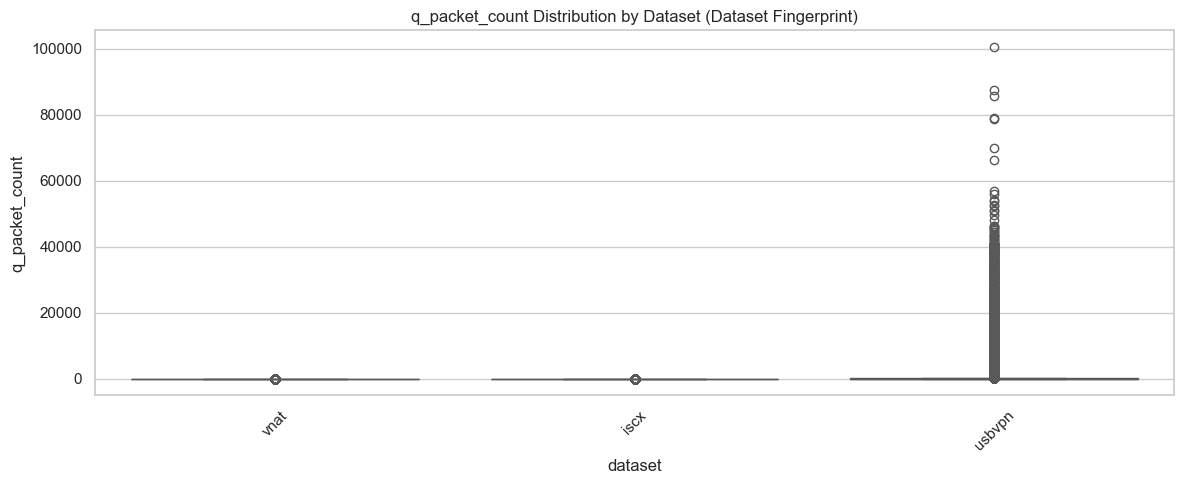

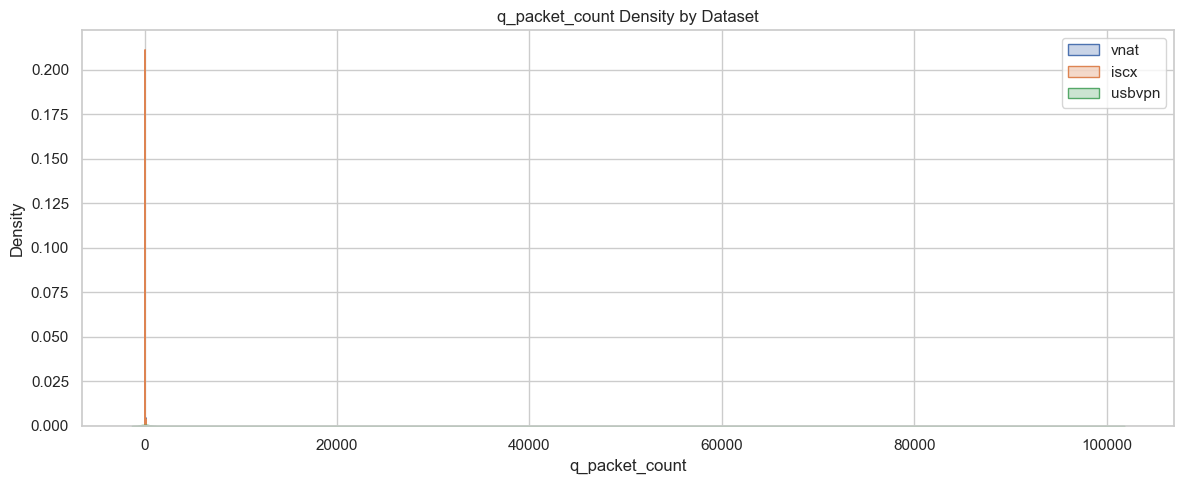


iat_std_min:
------------------------------------------------------------
             mean         std  min          max
dataset                                        
iscx     0.614524   10.840396  0.0   881.553458
usbvpn   0.162407    1.134133  0.0    62.025036
vnat     8.528342  166.029731  0.0  7771.777865


C:\Users\scoti\AppData\Local\Temp\ipykernel_14748\1240654760.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=forensic_df, x='dataset', y=feat, palette='Set2')


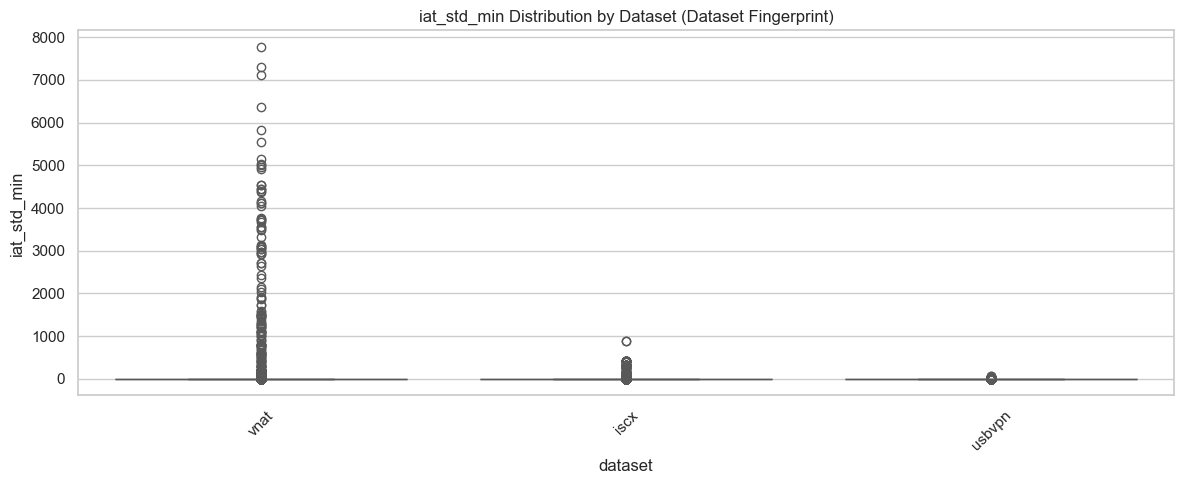

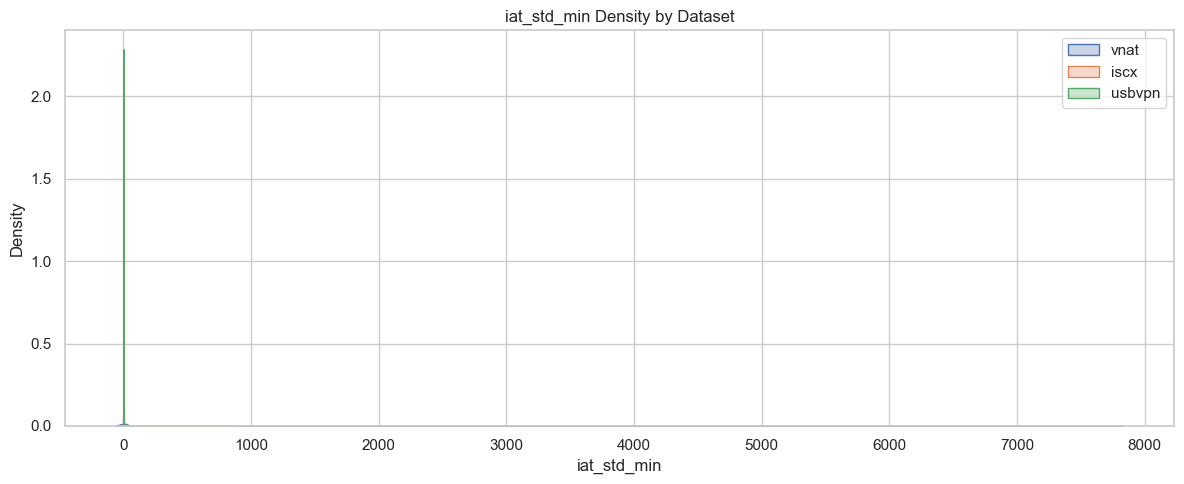


sz_std_max:
------------------------------------------------------------
               mean         std  min           max
dataset                                           
iscx      36.404482  239.337195  0.0  14809.227047
usbvpn   623.247609  458.460531  0.0   5122.798337
vnat      45.131661  136.621426  0.0    678.860270


C:\Users\scoti\AppData\Local\Temp\ipykernel_14748\1240654760.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=forensic_df, x='dataset', y=feat, palette='Set2')


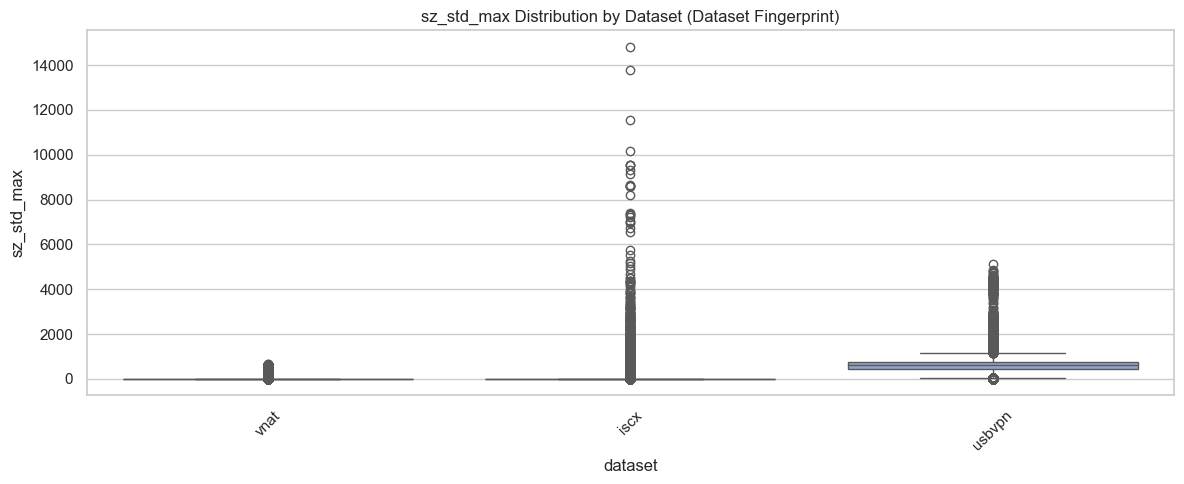

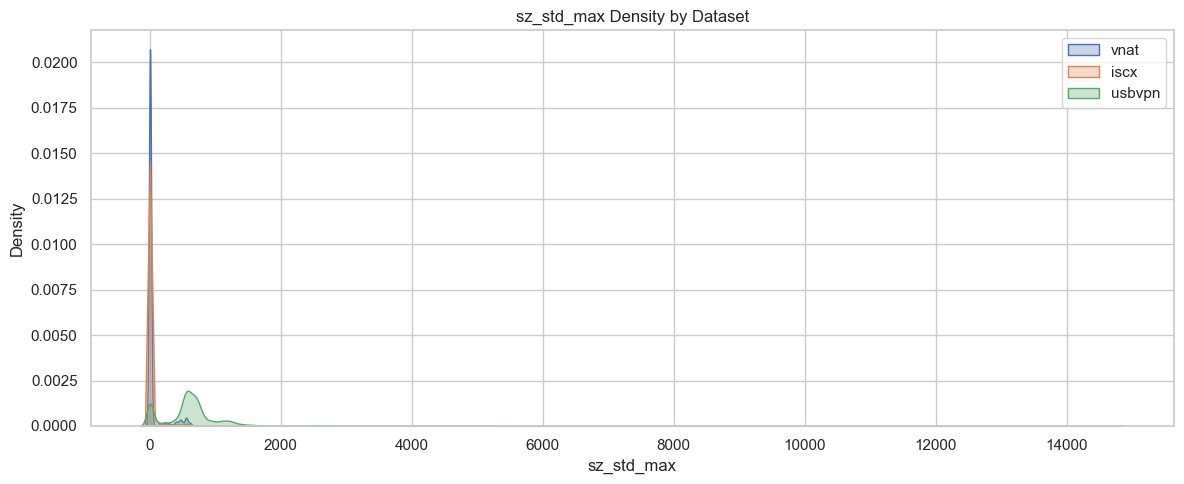

In [21]:
# Analyze top dataset-distinguishing features
print("\n--- Statistical Analysis of Top Dataset Fingerprint Features ---\n")

top_5_fingerprint = feature_importance.head(5)['feature'].tolist()

for feat in top_5_fingerprint:
    if feat in forensic_df.columns:
        print(f"\n{feat}:")
        print("-" * 60)
        
        # Statistics by dataset
        stats = forensic_df.groupby('dataset')[feat].agg(['mean', 'std', 'min', 'max'])
        print(stats)
        
        # Plot distribution
        plt.figure(figsize=(12, 5))
        sns.boxplot(data=forensic_df, x='dataset', y=feat, palette='Set2')
        plt.title(f'{feat} Distribution by Dataset (Dataset Fingerprint)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # KDE overlay
        plt.figure(figsize=(12, 5))
        for dataset in forensic_df['dataset'].unique():
            subset = forensic_df[forensic_df['dataset'] == dataset][feat]
            sns.kdeplot(subset, label=dataset, fill=True, alpha=0.3)
        plt.title(f'{feat} Density by Dataset')
        plt.xlabel(feat)
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()


6. CROSS-DATASET VPN CLASSIFICATION ANALYSIS
Testing how well VPN classifiers generalize across datasets


Cross-Dataset VPN Classification Results:
train_dataset test_dataset  accuracy  n_train  n_test
         vnat         iscx  0.747728    33711   76687
         vnat       usbvpn  0.845346    33711   58977
         iscx         vnat  0.954763    76687   33711
         iscx       usbvpn  0.735049    76687   58977
       usbvpn         vnat  0.985702    58977   33711
       usbvpn         iscx  0.708190    58977   76687


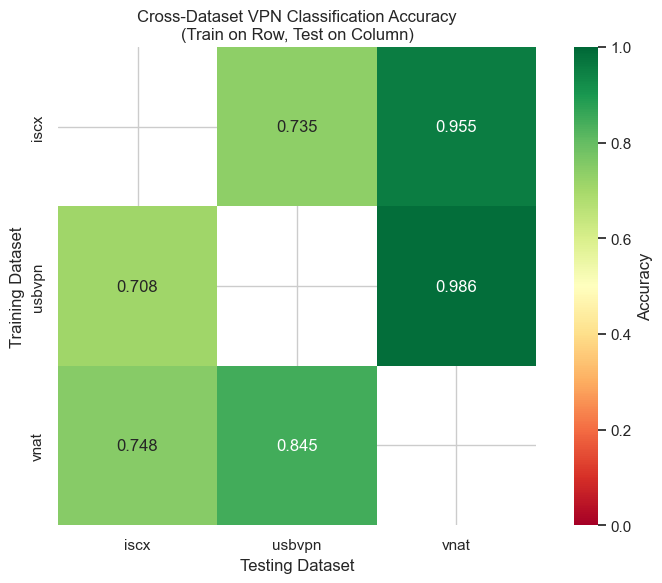


⚠️  INTERPRETATION:
  - Diagonal values would be in-domain performance (not shown here)
  - Low off-diagonal values indicate poor cross-dataset generalization
  - This suggests models are learning dataset-specific patterns, not VPN patterns


In [22]:
print("\n" + "="*60)
print("6. CROSS-DATASET VPN CLASSIFICATION ANALYSIS")
print("="*60)
print("Testing how well VPN classifiers generalize across datasets\n")

# Test 1: Train on one dataset, test on another
results = []

for train_ds in forensic_df['dataset'].unique():
    for test_ds in forensic_df['dataset'].unique():
        if train_ds == test_ds:
            continue
            
        # Prepare data
        train_data = forensic_df[forensic_df['dataset'] == train_ds].copy()
        test_data = forensic_df[forensic_df['dataset'] == test_ds].copy()
        
        # Check if both classes exist
        if len(train_data['label'].unique()) < 2 or len(test_data['label'].unique()) < 2:
            continue
        
        X_train_vpn = train_data[valid_features].fillna(train_data[valid_features].median())
        y_train_vpn = train_data['label']
        X_test_vpn = test_data[valid_features].fillna(train_data[valid_features].median())
        y_test_vpn = test_data['label']
        
        # Scale
        scaler_vpn = StandardScaler()
        X_train_vpn_scaled = scaler_vpn.fit_transform(X_train_vpn)
        X_test_vpn_scaled = scaler_vpn.transform(X_test_vpn)
        
        # Train VPN classifier
        rf_vpn = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        rf_vpn.fit(X_train_vpn_scaled, y_train_vpn)
        
        # Test
        y_pred_vpn = rf_vpn.predict(X_test_vpn_scaled)
        acc_vpn = (y_pred_vpn == y_test_vpn).mean()
        
        results.append({
            'train_dataset': train_ds,
            'test_dataset': test_ds,
            'accuracy': acc_vpn,
            'n_train': len(train_data),
            'n_test': len(test_data)
        })

# Display results
results_df = pd.DataFrame(results)
print("\nCross-Dataset VPN Classification Results:")
print(results_df.to_string(index=False))

# Pivot for heatmap
if not results_df.empty:
    pivot_results = results_df.pivot(index='train_dataset', columns='test_dataset', values='accuracy')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_results, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5, 
                vmin=0, vmax=1, square=True, cbar_kws={'label': 'Accuracy'})
    plt.title('Cross-Dataset VPN Classification Accuracy\n(Train on Row, Test on Column)')
    plt.ylabel('Training Dataset')
    plt.xlabel('Testing Dataset')
    plt.tight_layout()
    plt.show()
    
    print("\n⚠️  INTERPRETATION:")
    print("  - Diagonal values would be in-domain performance (not shown here)")
    print("  - Low off-diagonal values indicate poor cross-dataset generalization")
    print("  - This suggests models are learning dataset-specific patterns, not VPN patterns")


7. PER-DATASET FEATURE-LABEL CORRELATION COMPARISON
Identifying features that correlate with VPN label differently across datasets


Top 20 Features with Most Inconsistent Correlations Across Datasets:
(High variance = feature-label relationship changes by dataset)

                         vnat      iscx    usbvpn  std_across_datasets  mean_abs_corr
q_packet_count       0.091925  0.046004  0.623208             0.320815       0.253712
sz_coef_variation   -0.013178  0.334392 -0.285286             0.310604       0.210952
sz_p25_median_ratio -0.016381 -0.380493 -0.176463             0.182497       0.191113
sz_p75_median_ratio -0.012907  0.051648 -0.267481             0.168730       0.110679
sz_mean_max          0.002748  0.069444  0.242717             0.123866       0.104969
q_min_packets_ok     0.186210 -0.040442  0.093372             0.113942       0.106675
sz_mean_min         -0.038323  0.148687  0.060088             0.093548       0.082366
iat_all_std         -0.014846 -0.013148  0.0

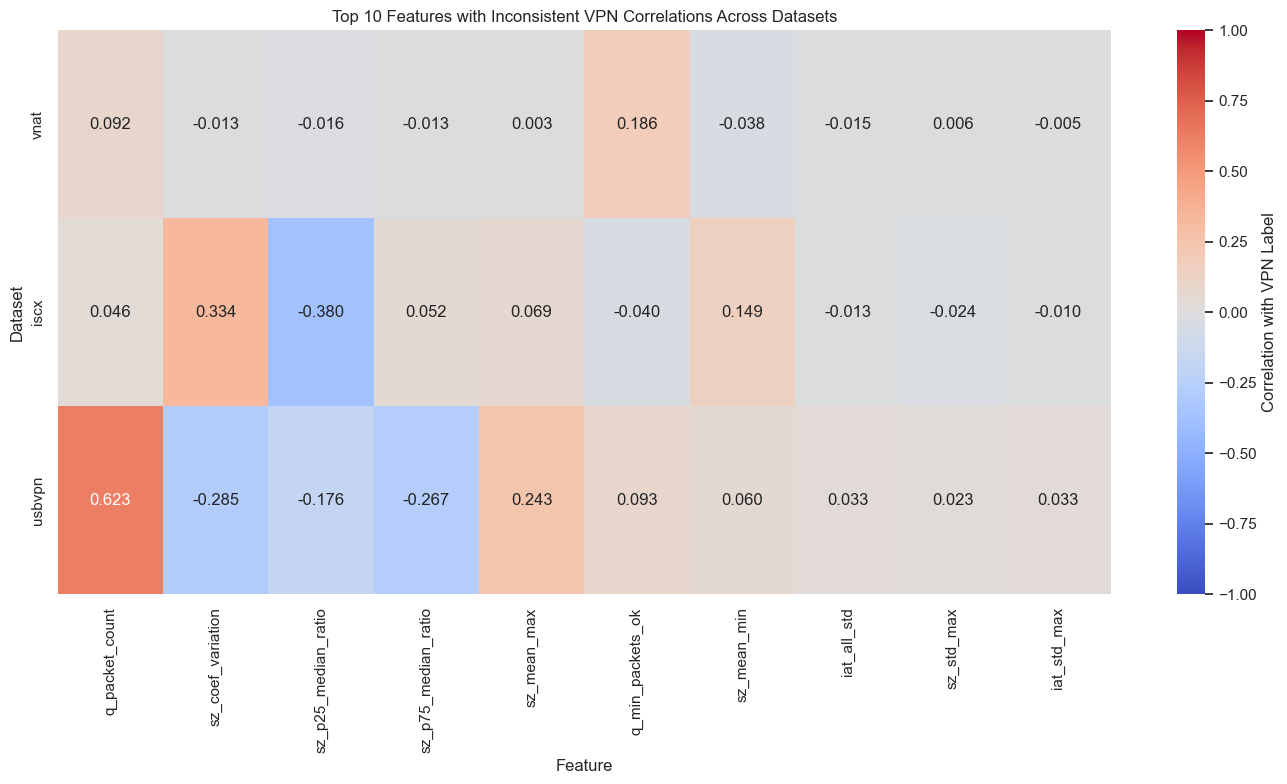


⚠️  INSIGHTS:
  - Features with high correlation variance are unreliable across domains
  - These features may work well within one dataset but fail to generalize
  - Consider focusing on features with LOW variance and HIGH mean correlation


In [23]:
print("\n" + "="*60)
print("7. PER-DATASET FEATURE-LABEL CORRELATION COMPARISON")
print("="*60)
print("Identifying features that correlate with VPN label differently across datasets\n")

# Calculate correlation with label for each dataset
correlation_comparison = pd.DataFrame()

for dataset in forensic_df['dataset'].unique():
    ds_data = forensic_df[forensic_df['dataset'] == dataset].copy()
    
    # Check if both classes exist
    if len(ds_data['label'].unique()) < 2:
        print(f"Skipping {dataset}: only one class present")
        continue
    
    # Calculate correlations
    ds_features = ds_data[valid_features + ['label']].copy()
    
    # Only keep features with variance
    feature_stds = ds_features.std()
    valid_ds_features = feature_stds[feature_stds > 0].index.tolist()
    valid_ds_features = [f for f in valid_ds_features if f != 'label']
    
    if valid_ds_features:
        corrs = ds_features[valid_ds_features].corrwith(ds_features['label'])
        correlation_comparison[dataset] = corrs

# Add column for correlation variance across datasets
if not correlation_comparison.empty:
    correlation_comparison['std_across_datasets'] = correlation_comparison.std(axis=1)
    correlation_comparison['mean_abs_corr'] = correlation_comparison.iloc[:, :-1].abs().mean(axis=1)
    
    # Sort by variance - features with high variance are dataset-specific
    correlation_comparison_sorted = correlation_comparison.sort_values('std_across_datasets', ascending=False)
    
    print("\nTop 20 Features with Most Inconsistent Correlations Across Datasets:")
    print("(High variance = feature-label relationship changes by dataset)\n")
    print(correlation_comparison_sorted.head(20).to_string())
    
    # Visualize top 10
    top_10_inconsistent = correlation_comparison_sorted.head(10)
    
    plt.figure(figsize=(14, 8))
    top_10_data = top_10_inconsistent.iloc[:, :-2]  # Exclude std and mean columns
    sns.heatmap(top_10_data.T, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlation with VPN Label'})
    plt.title('Top 10 Features with Inconsistent VPN Correlations Across Datasets')
    plt.xlabel('Feature')
    plt.ylabel('Dataset')
    plt.tight_layout()
    plt.show()
    
    print("\n⚠️  INSIGHTS:")
    print("  - Features with high correlation variance are unreliable across domains")
    print("  - These features may work well within one dataset but fail to generalize")
    print("  - Consider focusing on features with LOW variance and HIGH mean correlation")

In [24]:
# Find stable features - low variance, high correlation
if not correlation_comparison.empty:
    print("\n" + "="*60)
    print("8. STABLE FEATURES FOR CROSS-DATASET GENERALIZATION")
    print("="*60)
    
    # Define criteria for stable features
    # Low std_across_datasets (< 0.1) and high mean_abs_corr (> 0.1)
    stable_features = correlation_comparison[
        (correlation_comparison['std_across_datasets'] < 0.1) & 
        (correlation_comparison['mean_abs_corr'] > 0.1)
    ].sort_values('mean_abs_corr', ascending=False)
    
    print(f"\nFound {len(stable_features)} stable features (low variance, high correlation)\n")
    
    if len(stable_features) > 0:
        print("Top Stable Features for Cross-Dataset VPN Detection:")
        print(stable_features.head(20).to_string())
        
        # Visualize stable features
        if len(stable_features) >= 10:
            stable_top10 = stable_features.head(10)
        else:
            stable_top10 = stable_features
        
        if len(stable_top10) > 0:
            plt.figure(figsize=(14, 8))
            stable_data = stable_top10.iloc[:, :-2]  # Exclude std and mean columns
            sns.heatmap(stable_data.T, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                       vmin=-1, vmax=1, cbar_kws={'label': 'Correlation with VPN Label'})
            plt.title('Stable Features: Consistent VPN Correlations Across Datasets')
            plt.xlabel('Feature')
            plt.ylabel('Dataset')
            plt.tight_layout()
            plt.show()
            
            print("\n✅ RECOMMENDATION:")
            print("  - Use these stable features for cross-dataset training")
            print("  - They maintain consistent relationships with VPN labels across domains")
    else:
        print("⚠️  No features meet strict stability criteria (std < 0.1, mean_abs_corr > 0.1)")
        print("  Consider relaxing criteria or investigating why no features are stable")


8. STABLE FEATURES FOR CROSS-DATASET GENERALIZATION

Found 0 stable features (low variance, high correlation)

⚠️  No features meet strict stability criteria (std < 0.1, mean_abs_corr > 0.1)
  Consider relaxing criteria or investigating why no features are stable


In [25]:
print("\n" + "="*60)
print("9. SUMMARY REPORT: DATASET LEAKAGE FINDINGS")
print("="*60)

print(f"""
DATASET LEAKAGE ANALYSIS SUMMARY
================================

1. DATASET DISTINGUISHABILITY
   - Dataset Classification Accuracy: {accuracy_leak:.1%}
   - {'⚠️  HIGH LEAKAGE' if accuracy_leak > 0.8 else '✅ LOW LEAKAGE' if accuracy_leak < 0.6 else '⚠️  MODERATE LEAKAGE'}
   - Models can {'easily' if accuracy_leak > 0.8 else 'moderately' if accuracy_leak > 0.6 else 'barely'} identify which dataset a sample comes from

2. TOP DATASET FINGERPRINT FEATURES
   (Features that distinguish datasets, not VPN traffic):
""")

if len(feature_importance) > 0:
    for idx, row in feature_importance.head(5).iterrows():
        print(f"   - {row['feature']}: {row['importance']:.4f}")

print(f"""

3. CROSS-DATASET GENERALIZATION
   (How well VPN classifiers transfer across datasets):
""")

if not results_df.empty:
    avg_cross_acc = results_df['accuracy'].mean()
    print(f"   - Average cross-dataset accuracy: {avg_cross_acc:.1%}")
    print(f"   - {'⚠️  POOR' if avg_cross_acc < 0.6 else '✅ GOOD' if avg_cross_acc > 0.8 else '⚠️  MODERATE'} generalization")
    print("\n   Cross-dataset results:")
    for _, row in results_df.iterrows():
        print(f"     Train on {row['train_dataset']:8s} → Test on {row['test_dataset']:8s}: {row['accuracy']:.1%}")

print(f"""

4. FEATURE STABILITY ACROSS DATASETS
""")

if not correlation_comparison.empty:
    high_variance_features = correlation_comparison[correlation_comparison['std_across_datasets'] > 0.15]
    stable_count = len(stable_features) if len(stable_features) > 0 else 0
    
    print(f"   - {len(high_variance_features)} features have highly inconsistent correlations")
    print(f"   - {stable_count} features are stable across datasets")
    print(f"   - Stability status: {'⚠️  UNSTABLE' if stable_count < 5 else '✅ STABLE' if stable_count > 15 else '⚠️  MODERATE'}")

print(f"""

5. RECOMMENDATIONS
   a) {'Use domain adaptation techniques' if accuracy_leak > 0.8 else 'Current features show reasonable domain invariance'}
   b) {'Focus on stable features identified in Section 8' if stable_count > 0 else 'No stable features found - consider feature engineering'}
   c) {'Avoid top fingerprint features in Section 5' if accuracy_leak > 0.8 else 'Feature selection is adequate'}
   d) {'Train with mixed-domain batches' if avg_cross_acc < 0.7 else 'Standard training should work'}
   e) Consider dataset-specific normalization strategies

6. KEY INSIGHT
   {'Your models are learning dataset artifacts, not VPN patterns!' if accuracy_leak > 0.8 and avg_cross_acc < 0.6 else 'Features show reasonable cross-dataset generalization.' if accuracy_leak < 0.6 else 'Moderate dataset leakage detected - improvements needed.'}
""")


9. SUMMARY REPORT: DATASET LEAKAGE FINDINGS

DATASET LEAKAGE ANALYSIS SUMMARY

1. DATASET DISTINGUISHABILITY
   - Dataset Classification Accuracy: 98.7%
   - ⚠️  HIGH LEAKAGE
   - Models can easily identify which dataset a sample comes from

2. TOP DATASET FINGERPRINT FEATURES
   (Features that distinguish datasets, not VPN traffic):

   - sz_mean_max: 0.2077
   - sz_mean_min: 0.1197
   - q_packet_count: 0.0940
   - iat_std_min: 0.0924
   - sz_std_max: 0.0640


3. CROSS-DATASET GENERALIZATION
   (How well VPN classifiers transfer across datasets):

   - Average cross-dataset accuracy: 82.9%
   - ✅ GOOD generalization

   Cross-dataset results:
     Train on vnat     → Test on iscx    : 74.8%
     Train on vnat     → Test on usbvpn  : 84.5%
     Train on iscx     → Test on vnat    : 95.5%
     Train on iscx     → Test on usbvpn  : 73.5%
     Train on usbvpn   → Test on vnat    : 98.6%
     Train on usbvpn   → Test on iscx    : 70.8%


4. FEATURE STABILITY ACROSS DATASETS

   - 4 featur